 IMPLEMENTATION OF DIJKSTRA'S ALGORITHM FOR INDIAN CITY ROAD NETWORK

Available Indian Cities:
----------------------------------------------------------------------
 1. Agra
 2. Ahmedabad
 3. Amritsar
 4. Bangalore
 5. Bhopal
 6. Bhubaneswar
 7. Chandigarh
 8. Chennai
 9. Coimbatore
10. Dehradun
11. Delhi
12. Guwahati
13. Hyderabad
14. Indore
15. Jaipur
16. Jammu
17. Jodhpur
18. Kanpur
19. Kochi
20. Kolkata
21. Lucknow
22. Mumbai
23. Mysore
24. Nagpur
25. Patna
26. Prayagraj
27. Pune
28. Ranchi
29. Shillong
30. Srinagar
31. Thiruvananthapuram
32. Udaipur
33. Varanasi
34. Vijayawada
35. Visakhapatnam

 ENTER SOURCE AND DESTINATION

Enter source city: Hyderabad
Enter destination city: Delhi

 DIJKSTRA'S ALGORITHM RESULT

Source City      : Hyderabad
Destination City : Delhi

Shortest Route:
Hyderabad → Pune → Mumbai → Ahmedabad → Udaipur → Jaipur → Delhi

Total Road Distance : 2175 km
Cities in Shortest Path : 7
Cities Explored : 26

Visited Cities:
Agra, Ahmedabad, Bangalore, Bhopal, B

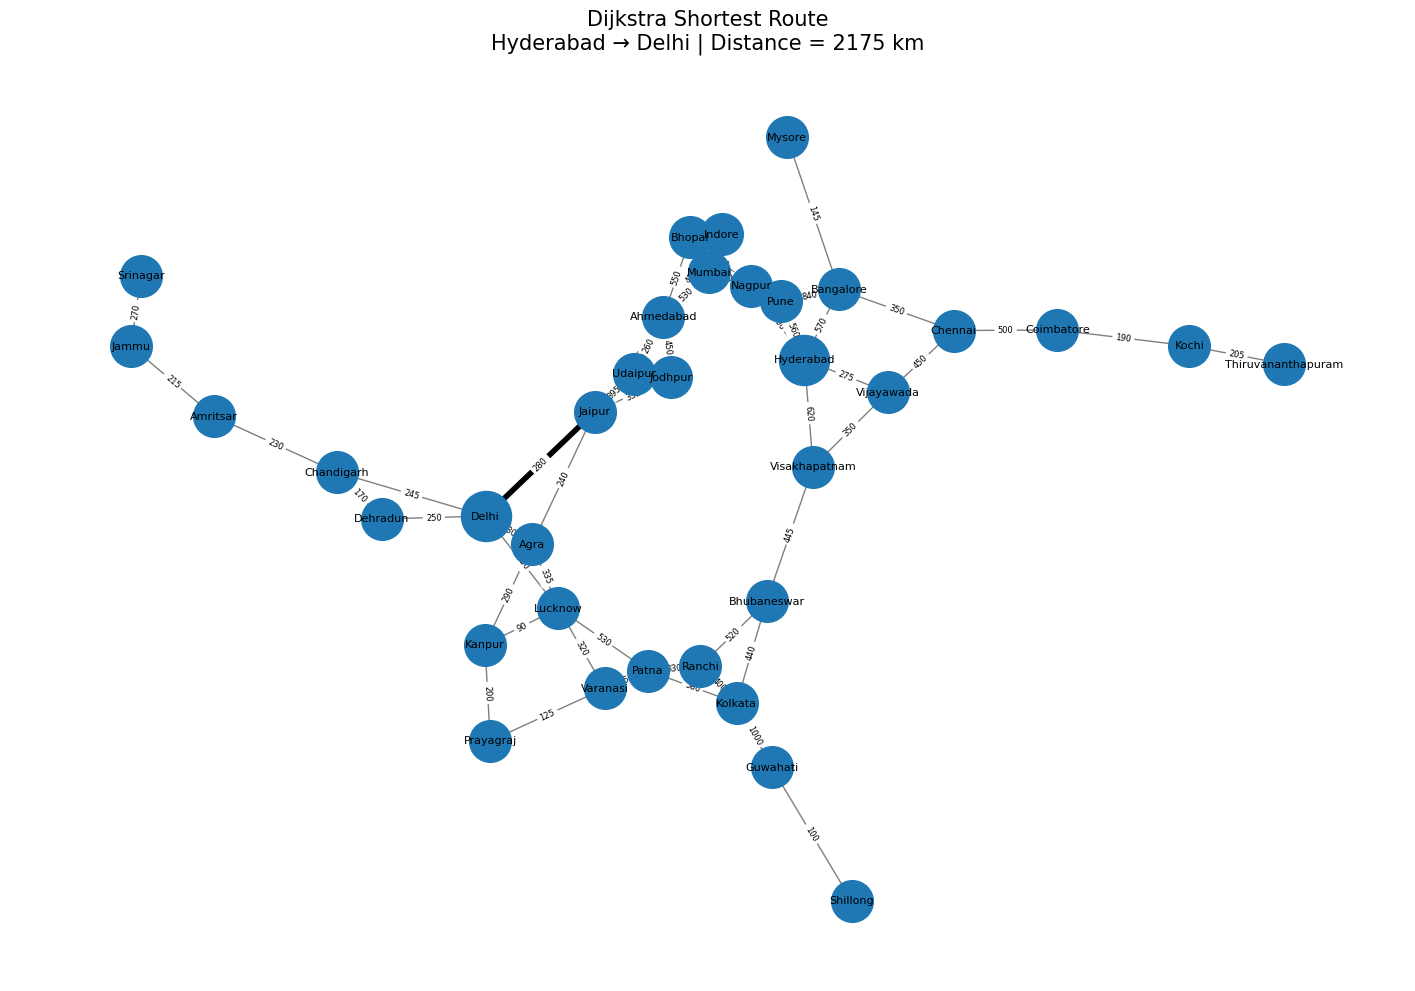


 PROJECT EXECUTION COMPLETED


In [1]:
# ================================================================
# M.Tech AI & DS - AI Assignment 2
# Programming Q1: Dijkstra's Algorithm for Indian City Road Network
# ================================================================

# -------------------- IMPORT LIBRARIES ---------------------------
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# -------------------- PROJECT TITLE ------------------------------
print("=" * 70)
print(" IMPLEMENTATION OF DIJKSTRA'S ALGORITHM FOR INDIAN CITY ROAD NETWORK")
print("=" * 70)

# -------------------- INDIAN CITY ROAD DISTANCE DATA -------------
# Approximate road distances in kilometres.
# The graph represents major Indian cities and their connecting roads.

road_data = [
    ("Delhi", "Jaipur", 280),
    ("Delhi", "Agra", 230),
    ("Delhi", "Chandigarh", 245),
    ("Delhi", "Lucknow", 550),
    ("Delhi", "Dehradun", 250),

    ("Jaipur", "Agra", 240),
    ("Jaipur", "Ahmedabad", 670),
    ("Jaipur", "Udaipur", 395),

    ("Agra", "Lucknow", 335),
    ("Agra", "Kanpur", 290),

    ("Lucknow", "Kanpur", 90),
    ("Lucknow", "Varanasi", 320),
    ("Lucknow", "Patna", 530),

    ("Kanpur", "Prayagraj", 200),
    ("Prayagraj", "Varanasi", 125),

    ("Varanasi", "Patna", 250),
    ("Varanasi", "Ranchi", 410),

    ("Patna", "Ranchi", 330),
    ("Patna", "Kolkata", 580),

    ("Ranchi", "Kolkata", 400),
    ("Ranchi", "Bhubaneswar", 520),

    ("Kolkata", "Bhubaneswar", 440),
    ("Kolkata", "Guwahati", 1000),

    ("Bhubaneswar", "Visakhapatnam", 445),

    ("Visakhapatnam", "Vijayawada", 350),
    ("Visakhapatnam", "Hyderabad", 620),

    ("Vijayawada", "Hyderabad", 275),
    ("Vijayawada", "Chennai", 450),

    ("Hyderabad", "Bangalore", 570),
    ("Hyderabad", "Nagpur", 500),

    ("Bangalore", "Chennai", 350),
    ("Bangalore", "Mysore", 145),

    ("Chennai", "Coimbatore", 500),

    ("Coimbatore", "Kochi", 190),

    ("Kochi", "Thiruvananthapuram", 205),

    ("Nagpur", "Bhopal", 350),
    ("Nagpur", "Mumbai", 800),

    ("Bhopal", "Indore", 195),
    ("Bhopal", "Ahmedabad", 550),

    ("Indore", "Ahmedabad", 400),
    ("Indore", "Mumbai", 585),

    ("Ahmedabad", "Mumbai", 530),
    ("Ahmedabad", "Udaipur", 260),

    ("Mumbai", "Pune", 150),
    ("Pune", "Hyderabad", 560),

    ("Pune", "Bangalore", 840),

    ("Chandigarh", "Amritsar", 230),
    ("Chandigarh", "Dehradun", 170),

    ("Guwahati", "Shillong", 100),

    ("Srinagar", "Jammu", 270),
    ("Jammu", "Amritsar", 215),

    ("Jodhpur", "Jaipur", 335),
    ("Jodhpur", "Ahmedabad", 450)
]

# -------------------- CREATE GRAPH -------------------------------
graph = {}

for city1, city2, distance in road_data:
    graph.setdefault(city1, [])
    graph.setdefault(city2, [])

    # Road network is bidirectional
    graph[city1].append((city2, distance))
    graph[city2].append((city1, distance))

# -------------------- DIJKSTRA'S ALGORITHM -----------------------
def dijkstra(graph, start, goal):

    # Distance from start to every city
    distances = {city: float('inf') for city in graph}
    distances[start] = 0

    # To reconstruct shortest path
    previous = {city: None for city in graph}

    # Priority queue: (distance, city)
    priority_queue = [(0, start)]

    visited = set()

    while priority_queue:

        current_distance, current_city = heapq.heappop(priority_queue)

        # Ignore already processed cities
        if current_city in visited:
            continue

        visited.add(current_city)

        # Stop when destination is reached
        if current_city == goal:
            break

        # Check neighbouring cities
        for neighbour, road_distance in graph[current_city]:

            new_distance = current_distance + road_distance

            if new_distance < distances[neighbour]:

                distances[neighbour] = new_distance
                previous[neighbour] = current_city

                heapq.heappush(
                    priority_queue,
                    (new_distance, neighbour)
                )

    # If destination cannot be reached
    if distances[goal] == float('inf'):
        return None, None, visited

    # Reconstruct shortest path
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = previous[current]

    path.reverse()

    return path, distances[goal], visited


# -------------------- DISPLAY AVAILABLE CITIES -------------------
cities = sorted(graph.keys())

print("\nAvailable Indian Cities:")
print("-" * 70)

for i, city in enumerate(cities, start=1):
    print(f"{i:2}. {city}")

# -------------------- USER INPUT ---------------------------------
print("\n" + "=" * 70)
print(" ENTER SOURCE AND DESTINATION")
print("=" * 70)

source = input("\nEnter source city: ").strip().title()
destination = input("Enter destination city: ").strip().title()

# -------------------- VALIDATE INPUT ------------------------------
if source not in graph:
    print(f"\n❌ Source city '{source}' is not available in the dataset.")

elif destination not in graph:
    print(f"\n❌ Destination city '{destination}' is not available in the dataset.")

else:

    # Run Dijkstra
    shortest_path, total_distance, visited = dijkstra(
        graph,
        source,
        destination
    )

    if shortest_path is None:

        print("\n❌ No route found between the selected cities.")

    else:

        # -------------------- RESULT ------------------------------
        print("\n" + "=" * 70)
        print(" DIJKSTRA'S ALGORITHM RESULT")
        print("=" * 70)

        print(f"\nSource City      : {source}")
        print(f"Destination City : {destination}")

        print("\nShortest Route:")
        print(" → ".join(shortest_path))

        print(f"\nTotal Road Distance : {total_distance} km")

        print(f"Cities in Shortest Path : {len(shortest_path)}")

        print(f"Cities Explored : {len(visited)}")

        print("\nVisited Cities:")
        print(", ".join(sorted(visited)))

        print("\n" + "=" * 70)
        print(" OBSERVATION")
        print("=" * 70)

        print(
            f"Dijkstra's algorithm found the shortest route from "
            f"{source} to {destination} with a total road distance "
            f"of {total_distance} km."
        )

        print(
            "\nThe algorithm always selects the unvisited city with "
            "the smallest known distance from the source."
        )

        # -------------------- GRAPH VISUALIZATION -----------------
        print("\nGenerating road network visualization...")

        G = nx.Graph()

        for city1, city2, distance in road_data:
            G.add_edge(city1, city2, weight=distance)

        # Use spring layout for visualization
        plt.figure(figsize=(18, 12))

        pos = nx.spring_layout(
            G,
            seed=42,
            k=1.5
        )

        # Draw complete road network
        nx.draw_networkx_nodes(
            G,
            pos,
            node_size=900
        )

        nx.draw_networkx_edges(
            G,
            pos,
            width=1,
            alpha=0.5
        )

        nx.draw_networkx_labels(
            G,
            pos,
            font_size=8
        )

        # Highlight shortest path
        path_edges = list(
            zip(shortest_path[:-1], shortest_path[1:])
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            width=4
        )

        # Highlight source and destination
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[source],
            node_size=1300
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[destination],
            node_size=1300
        )

        # Edge distance labels
        edge_labels = nx.get_edge_attributes(
            G,
            "weight"
        )

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=6
        )

        plt.title(
            f"Dijkstra Shortest Route\n"
            f"{source} → {destination} | "
            f"Distance = {total_distance} km",
            fontsize=15
        )

        plt.axis("off")
        plt.show()

# -------------------- END ----------------------------------------
print("\n" + "=" * 70)
print(" PROJECT EXECUTION COMPLETED")
print("=" * 70)